### Tutorial 08: Structured Lighting

In [2]:
import bpy
import bmesh
import numpy as np
import matplotlib.pyplot as plt
import import_ipynb
import itertools

from L001_hello_world import render, clear_scene

# Clear scene
if __name__ == '__main__':
    clear_scene()

In [3]:
# Set render engine for ray tracing
bpy.context.scene.render.engine = 'CYCLES'
bpy.context.scene.render.resolution_x = 512
bpy.context.scene.render.resolution_y = 512
bpy.context.scene.render.image_settings.file_format = 'HDR'
bpy.context.scene.view_settings.view_transform = 'Raw'
bpy.context.scene.cycles.use_adaptive_sampling = False
bpy.context.scene.cycles.samples = 100
bpy.context.scene.cycles.use_denoising = False

In [4]:
# Create camera
bpy.ops.object.camera_add(rotation=(0, 0, 0), location=(1,0,0))
cam = bpy.context.active_object
cam.data.sensor_width = cam.data.lens
bpy.context.scene.camera = cam

# Add plane to scene
bpy.ops.mesh.primitive_monkey_add(size=5, location=(1, 0, -8), rotation=(3*np.pi/2, 0, 0))
plane = bpy.context.active_object

In [5]:
def createProjector():
    # Create a new spotlight
    bpy.ops.object.light_add(type='SPOT', location=(0, 0, 0))
    spotlight = bpy.context.active_object
    spotlight.data.energy = 2000
    spotlight.data.spot_size = np.pi
    spotlight.data.spot_blend = 0

    N = 512
    image = bpy.data.images.new('pattern', N, N)
    image.colorspace_settings.name = 'Non-Color'

    nodes = spotlight.data.node_tree.nodes
    nodes.clear()

    node1 = nodes.new('ShaderNodeNewGeometry')
    node2 = nodes.new('ShaderNodeVectorTransform')
    node2.vector_type = 'NORMAL'
    node3 = nodes.new('ShaderNodeSeparateXYZ')
    node4 = nodes.new('ShaderNodeVectorMath')
    node4.operation = 'DIVIDE'
    node5 = nodes.new('ShaderNodeMapping')
    node5.inputs['Location'].default_value = (0.5, 0.5, 0)
    node6 = nodes.new('ShaderNodeTexImage')
    node6.interpolation = 'Closest'
    node6.extension = 'CLIP'
    node6.image = image
    node7 = nodes.new('ShaderNodeOutputLight')

    node1.location = (0,0)
    node2.location = (200,0)
    node3.location = (400,0)
    node4.location = (600,0)
    node5.location = (800,0)
    node6.location = (1000,0)
    node7.location = (1300,0)

    links = spotlight.data.node_tree.links

    links.new(node1.outputs['Incoming'], node2.inputs['Vector'])
    links.new(node2.outputs['Vector'], node3.inputs['Vector'])
    links.new(node2.outputs['Vector'], node4.inputs['Vector'])
    links.new(node3.outputs['Z'], node4.inputs['Vector_001'])
    links.new(node4.outputs['Vector'], node5.inputs['Vector'])
    links.new(node5.outputs['Vector'], node6.inputs['Vector'])
    links.new(node6.outputs['Color'], node7.inputs['Surface'])


createProjector()

![](./figures/L008_fig1.png)

(512, 512)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.28125].


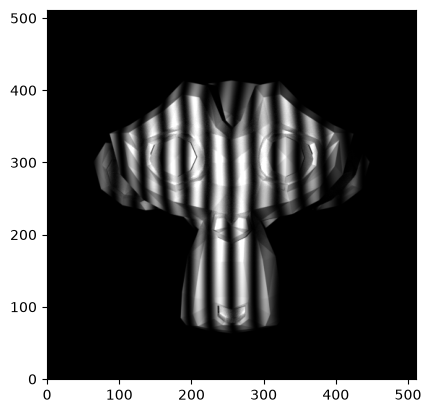

In [6]:
import math

N = 512

X, Y = np.meshgrid(range(N), range(N))
#X = X.astype('int')

image = bpy.data.images['pattern']
buffer = np.zeros((N,N,4))

path = "./tmp/output.png"
bpy.context.scene.render.filepath = path

print(X.shape)
pattern = 0.5*np.cos(X*0.2)+0.5
    
buffer[:,:,:] = pattern[:,:,None]
buffer[:,:,3] = 1
image.pixels = buffer.ravel()

plt.imshow(render(), origin='lower')

In [7]:
N = 512

X, Y = np.meshgrid(range(N), range(N))
X = X.astype('int')

image = bpy.data.images['pattern']
buffer = np.zeros((N,N,4))

path = "./tmp/output.hdr"
bpy.context.scene.render.filepath = path

disparity = 0

bit = N//2
while bit:
    pattern = np.bitwise_and(X,bit)
    
    buffer[:,:,:] = pattern[:,:,None]
    buffer[:,:,3] = 1
    image.pixels = buffer.ravel()

    bpy.ops.render.render(write_still=True)

    render = bpy.data.images.load(path)
    width, height = render.size
    pixels = np.array(render.pixels)
    pixels = pixels.reshape((height, width, 4))
    img0 = pixels[:,:,0:3]


    buffer[:,:,:] = 1-pattern[:,:,None]
    buffer[:,:,3] = 1
    image.pixels = buffer.ravel()

    bpy.ops.render.render(write_still=True)

    render = bpy.data.images.load(path)
    width, height = render.size
    pixels = np.array(render.pixels)
    pixels = pixels.reshape((height, width, 4))
    img1 = pixels[:,:,0:3]

    disparity = np.left_shift(disparity,1)
    disparity = disparity + (img1 > img0).astype('int')

    bit = np.right_shift(bit,1)

00:35.206  render           | Saved: 'tmp/output.hdr'
00:35.720  render           | Saved: 'tmp/output.hdr'
00:36.209  render           | Saved: 'tmp/output.hdr'
00:36.696  render           | Saved: 'tmp/output.hdr'
00:37.202  render           | Saved: 'tmp/output.hdr'
00:37.707  render           | Saved: 'tmp/output.hdr'
00:38.213  render           | Saved: 'tmp/output.hdr'
00:38.701  render           | Saved: 'tmp/output.hdr'
00:39.190  render           | Saved: 'tmp/output.hdr'
00:39.678  render           | Saved: 'tmp/output.hdr'
00:40.169  render           | Saved: 'tmp/output.hdr'
00:40.680  render           | Saved: 'tmp/output.hdr'
00:41.218  render           | Saved: 'tmp/output.hdr'
00:41.724  render           | Saved: 'tmp/output.hdr'
00:42.224  render           | Saved: 'tmp/output.hdr'
00:42.716  render           | Saved: 'tmp/output.hdr'
00:43.232  render           | Saved: 'tmp/output.hdr'
00:43.748  render           | Saved: 'tmp/output.hdr'


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.11..2.02].


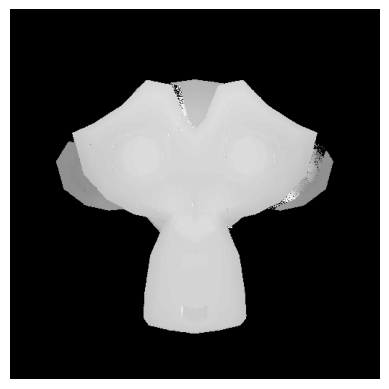

In [8]:
plt.imshow(1e-2*(disparity-X[:,:,None]), origin='lower')
plt.axis('off');

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0078125].


<bpy_int[2], Image.size>


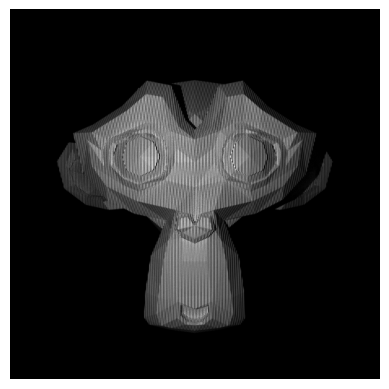

In [9]:
render_result = bpy.data.images['Render Result']

print(render_result.size)
width, height = render.size
pixels = np.array(render.pixels)
pixels = pixels.reshape((height, width, 4))

plt.imshow(pixels[:,:,0:3], origin='lower')
plt.axis('off');